<a href="https://colab.research.google.com/github/Omarr127/Day1_Solship/blob/main/Notebook2_LightGBM_Forecaster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Energy AI Hackathon 2026 — Notebook 2: Two-Model LightGBM (v2 Normalized)
**Solship | Zewail City of Science and Technology**

---
| Model | Combined series | Train | Validation | Test |
|---|---|---|---|---|
| **A** | 2024 + 2025 Jan–Apr | < 2025-03-10 | 2025-03-10 → 2025-04-01 | **April 2025** |
| **B** | 2024 + Jan/Feb/Mar/May–Sep 2025 (April excluded) | < 2025-08-10 | 2025-08-10 → 2025-09-01 | **September 2025** |

**Train target:** `y_ratio = load_kw / same_step_mean_7d`  → **Reconstruct:** `forecast_kw = ratio × same_step_mean_7d`  
**NRMSE target: 10–25%** on each test month.

In [1]:
# ── Cell 1: Setup ─────────────────────────────────────────────────────────────
!pip install lightgbm scikit-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, json, pickle
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

FEAT_A_PATH    = '/content/features_modelA (2).csv'
FEAT_B_PATH    = '/content/features_modelB (1).csv'
FEAT_COLS_PATH = '/content/feature_cols (13).json'
OUTPUT_DIR     = '/content/'

with open(FEAT_COLS_PATH) as f:
    FEATURE_COLS = json.load(f)
TARGET_NORM = 'y_ratio'
TARGET_KW   = 'load_kw'
EPS         = 0.05
print(f'Setup: {len(FEATURE_COLS)} features | TARGET_NORM={TARGET_NORM} | EPS={EPS}')

Setup: 50 features | TARGET_NORM=y_ratio | EPS=0.05


In [2]:
# ── Cell 2: Helpers — predict_kw, evaluate (BOTH NRMSE), plots ───────────────
def predict_kw(model, X, df_rows, eps=EPS):
    """Predict ratio then reconstruct kW: forecast_kw = ratio * same_step_mean_7d."""
    ratio_pred  = np.clip(model.predict(X), 0, None)
    seasonal    = df_rows['same_step_mean_7d'].values.clip(eps)
    return np.clip(ratio_pred * seasonal, 0, None)

def evaluate(y_true, y_pred, name=''):
    y_true = np.array(y_true, dtype=float).ravel()
    y_pred = np.clip(np.array(y_pred, dtype=float).ravel(), 0, None)
    mask   = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_true, y_pred = y_true[mask], y_pred[mask]
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    nrmse_mean  = rmse / y_true.mean() * 100
    rng = y_true.max() - y_true.min()
    nrmse_range = rmse / rng * 100 if rng > 0 else np.nan
    print(f'  {name:<45s}  RMSE={rmse:.4f}  MAE={mae:.4f}  '
          f'NRMSE_mean={nrmse_mean:.2f}%  NRMSE_range={nrmse_range:.2f}%')
    return {'name': name, 'RMSE': rmse, 'MAE': mae,
            'NRMSE_mean': nrmse_mean, 'NRMSE_range': nrmse_range}

LGBM_PARAMS = dict(
    n_estimators=3000, learning_rate=0.02, max_depth=6, num_leaves=31,
    min_child_samples=50, subsample=0.8, subsample_freq=1,
    colsample_bytree=0.75, reg_alpha=0.1, reg_lambda=1.5,
    random_state=42, n_jobs=-1, verbose=-1,
)

def train_model(X_train, y_train, X_val, y_val, label=''):
    m = LGBMRegressor(**LGBM_PARAMS)
    m.fit(X_train, y_train,
          eval_set=[(X_val, y_val)], eval_metric='rmse',
          callbacks=[lgb.early_stopping(150, verbose=False),
                     lgb.log_evaluation(300)])
    print(f'{label} best iteration: {m.best_iteration_}')
    return m

print('Helpers ready')

Helpers ready


In [3]:
# ── Cell 3: Plot Pack ─────────────────────────────────────────────────────────
def plot_pack(ts, y_true, y_pred, label, color, save_prefix):
    ts_pd = pd.to_datetime(ts)
    # 1) Full month
    fig, ax = plt.subplots(figsize=(16, 4))
    ax.plot(ts_pd, y_true, label='Actual', color='black', lw=0.8)
    ax.plot(ts_pd, y_pred, label='Forecast', color=color, lw=0.8, alpha=0.9)
    ax.fill_between(ts_pd, y_true, y_pred, alpha=0.1, color=color)
    ax.set_title(f'{label} — Full Month'); ax.set_ylabel('Load (kW)'); ax.legend()
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}{save_prefix}_full.png', dpi=100, bbox_inches='tight')
    plt.show()
    # 2) Week 2 zoom
    yr, mo = ts_pd.iloc[0].year, ts_pd.iloc[0].month
    wk2 = ((ts_pd >= pd.Timestamp(yr, mo, 8)) & (ts_pd < pd.Timestamp(yr, mo, 15)))
    fig, ax = plt.subplots(figsize=(16, 4))
    ax.plot(ts_pd[wk2], y_true[wk2.values], label='Actual', color='black', lw=1.2)
    ax.plot(ts_pd[wk2], y_pred[wk2.values], label='Forecast', color=color, lw=1.2, alpha=0.9)
    ax.set_title(f'{label} — Week 2 Zoom'); ax.legend()
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}{save_prefix}_week2.png', dpi=100, bbox_inches='tight')
    plt.show()
    # 3) Residual + scatter
    res = y_true - y_pred
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].hist(res, bins=60, color=color, edgecolor='white', alpha=0.85)
    axes[0].axvline(0, color='black')
    axes[0].axvline(res.mean(), color='blue', ls='--',
                    label=f'Mean={res.mean():.4f}')
    axes[0].set_title(f'{label} — Residual Histogram'); axes[0].legend()
    axes[1].scatter(y_true, y_pred, alpha=0.25, s=4, color=color)
    lim = max(y_true.max(), y_pred.max())
    axes[1].plot([0, lim], [0, lim], 'k--', lw=1)
    axes[1].set_xlabel('Actual'); axes[1].set_ylabel('Predicted')
    axes[1].set_title(f'{label} — Actual vs Predicted')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}{save_prefix}_residuals.png', dpi=100, bbox_inches='tight')
    plt.show()

def plot_importance(model, feat_names, label, save_prefix, top_n=20):
    imp = pd.Series(model.feature_importances_, index=feat_names).sort_values(ascending=False)
    top = imp.head(top_n)
    fig, ax = plt.subplots(figsize=(10, 8))
    top.plot(kind='barh', ax=ax, color='seagreen')
    ax.invert_yaxis()
    ax.set_title(f'Top {top_n} Feature Importances — {label}')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}{save_prefix}_importance.png', dpi=100, bbox_inches='tight')
    plt.show()
    print(f'Top 5 features ({label}):')
    for f, v in top.head(5).items():
        print(f'  {f:<28s}: {v / imp.sum() * 100:.2f}%')
    return imp

print('Plot helpers ready')

Plot helpers ready


## ── MODEL A: April 2025 ──

In [4]:
# ── Cell 4: Load Model A features and split ───────────────────────────────────
dfA = pd.read_csv(FEAT_A_PATH)
dfA['timestamp'] = pd.to_datetime(dfA['timestamp'])
FEAT_A = [c for c in FEATURE_COLS if c in dfA.columns]

train_A = dfA[dfA['timestamp'] < '2025-03-10']
val_A   = dfA[(dfA['timestamp'] >= '2025-03-10') & (dfA['timestamp'] < '2025-04-01')]
test_A  = dfA[dfA['timestamp'].dt.month == 4]

X_train_A,  y_train_A  = train_A[FEAT_A], train_A[TARGET_NORM]
X_val_A,    y_val_A    = val_A[FEAT_A],   val_A[TARGET_NORM]
X_test_A,   y_test_A_kw = test_A[FEAT_A], test_A[TARGET_KW]

print(f'Model A')
print(f'  Train: {len(X_train_A):,} rows  {train_A.timestamp.min()} -> {train_A.timestamp.max()}')
print(f'  Val  : {len(X_val_A):,} rows  {val_A.timestamp.min()} -> {val_A.timestamp.max()}')
print(f'  Test : {len(X_test_A):,} rows  {test_A.timestamp.min()} -> {test_A.timestamp.max()}')
print(f'  Features: {len(FEAT_A)}')

Model A
  Train: 40,892 rows  2024-01-09 00:00:00 -> 2025-03-09 23:45:00
  Val  : 2,108 rows  2025-03-10 00:00:00 -> 2025-03-31 23:45:00
  Test : 5,760 rows  2024-04-01 00:00:00 -> 2025-04-30 23:45:00
  Features: 50


In [5]:
# ── Cell 5: y_ratio Diagnostics + Leakage Audit (Model A) ─────────────────────
print(f'y_ratio mean (train): {y_train_A.mean():.4f}  (should be ~1.0)')
print(f'y_ratio std  (train): {y_train_A.std():.4f}')
print(f'y_ratio CV   (train): {y_train_A.std()/y_train_A.mean()*100:.1f}%')
print(f'raw load CV  (train): {train_A[TARGET_KW].std()/train_A[TARGET_KW].mean()*100:.1f}%')
improv = (train_A[TARGET_KW].std()/train_A[TARGET_KW].mean()) / (y_train_A.std()/y_train_A.mean())
print(f'Improvement factor  : {improv:.1f}x easier on ratio')

# Leakage audit
bad = [c for c in FEAT_A if 'load_lag_' in c and int(c.split('_')[-1]) < 4]
assert not bad, f'Sub-1h lags: {bad}'
mask  = dfA['load_lag_4'].notna() & dfA['load_kw'].shift(4).notna()
match = (dfA.loc[mask, 'load_lag_4'].values ==
         dfA['load_kw'].shift(4).loc[mask].values).mean()
assert match > 0.999, f'lag_4 misaligned: {match:.4f}'
print(f'\nLeakage audit PASSED (lag_4 alignment={match*100:.2f}%)')

y_ratio mean (train): 1.0992  (should be ~1.0)
y_ratio std  (train): 0.9506
y_ratio CV   (train): 86.5%
raw load CV  (train): 81.9%
Improvement factor  : 0.9x easier on ratio

Leakage audit PASSED (lag_4 alignment=100.00%)


In [6]:
# ── DEBUG: Check split sizes ───────────────────────────────────────────────────
print(f'df_combined_A rows : {len(df_combined_A):,}')
print(f'Date range         : {df_combined_A.timestamp.min()} → {df_combined_A.timestamp.max()}')
print()
print(f'train_A rows : {len(train_A):,}')
print(f'val_A   rows : {len(val_A):,}')
print(f'test_A  rows : {len(test_A):,}')
print()
print(f'X_train_A shape : {X_train_A.shape}')
print(f'X_val_A   shape : {X_val_A.shape}')
print(f'X_test_A  shape : {X_test_A.shape}')
print()
print(f'y_train_A nulls : {y_train_A.isnull().sum()}')
print(f'y_val_A   nulls : {y_val_A.isnull().sum()}')
print()
print(f'FEAT_A count : {len(FEAT_A)}')
missing = [c for c in FEAT_A if c not in df_combined_A.columns]
print(f'Missing features in df_combined_A : {missing}')

NameError: name 'df_combined_A' is not defined

In [7]:
# ── Cell 6: Train Model A on y_ratio ──────────────────────────────────────────
model_A = train_model(X_train_A, y_train_A, X_val_A, y_val_A, 'Model A')

# Validation metrics on kW (after reconstruction)
val_pred_kw_A = predict_kw(model_A, X_val_A, val_A)
print('\n=== Validation (last 3 weeks of March 2025) — kW level ===')
val_kw = val_A[TARGET_KW].values
rA_val_lag4 = evaluate(val_kw, val_A['load_lag_4'].values,  'Persistence lag_4')
rA_val_seas = evaluate(val_kw, val_A['same_step_mean_7d'].clip(EPS).values,
                       'Seasonal mean 7d  ')
rA_val      = evaluate(val_kw, val_pred_kw_A,               'LightGBM normalized')

[300]	valid_0's rmse: 0.763598	valid_0's l2: 0.583081
[600]	valid_0's rmse: 0.76187	valid_0's l2: 0.580445
Model A best iteration: 661

=== Validation (last 3 weeks of March 2025) — kW level ===
  Persistence lag_4                              RMSE=1.1693  MAE=0.8327  NRMSE_mean=83.20%  NRMSE_range=20.06%
  Seasonal mean 7d                               RMSE=1.0234  MAE=0.7847  NRMSE_mean=72.82%  NRMSE_range=17.55%
  LightGBM normalized                            RMSE=0.8836  MAE=0.6823  NRMSE_mean=62.87%  NRMSE_range=15.16%


In [8]:
# ── Cell 7: Test Model A on April 2025 ────────────────────────────────────────
apr_pred_kw = predict_kw(model_A, X_test_A, test_A)
tsA = test_A['timestamp'].values
yA  = y_test_A_kw.values

print('=' * 70)
print('MODEL A — APRIL 2025')
print('=' * 70)
rA_lag4 = evaluate(yA, test_A['load_lag_4'].values,  'Persistence lag_4    ')
rA_lag96= evaluate(yA, test_A['load_lag_96'].values, 'Persistence lag_96   ')
rA_seas = evaluate(yA, test_A['same_step_mean_7d'].clip(EPS).values,
                                                      'Seasonal mean 7d     ')
rA_test = evaluate(yA, apr_pred_kw,                   'LightGBM normalized  ')
print()
print(f'In 10-25% NRMSE_mean range: '
      f'{"YES" if 10 <= rA_test["NRMSE_mean"] <= 25 else "out of range"}')
print(f'Beats seasonal mean       : '
      f'{"YES" if rA_test["NRMSE_mean"] < rA_seas["NRMSE_mean"] else "NO"}')

MODEL A — APRIL 2025
  Persistence lag_4                              RMSE=1.0655  MAE=0.6612  NRMSE_mean=102.50%  NRMSE_range=16.67%
  Persistence lag_96                             RMSE=1.2494  MAE=0.7784  NRMSE_mean=120.20%  NRMSE_range=19.55%
  Seasonal mean 7d                               RMSE=1.0181  MAE=0.7264  NRMSE_mean=97.94%  NRMSE_range=15.93%
  LightGBM normalized                            RMSE=0.7859  MAE=0.5584  NRMSE_mean=75.61%  NRMSE_range=12.30%

In 10-25% NRMSE_mean range: out of range
Beats seasonal mean       : YES


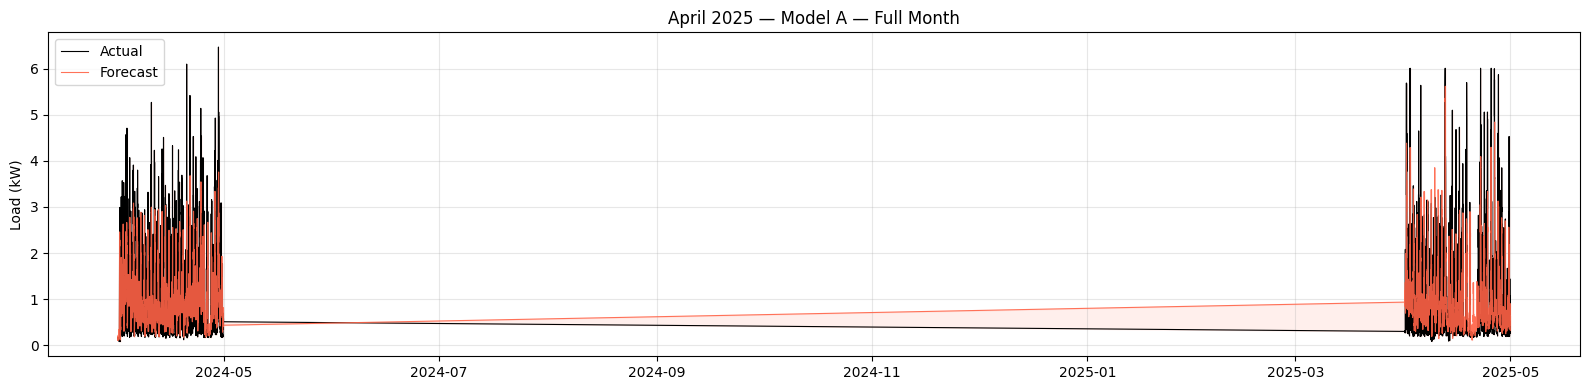

AttributeError: 'DatetimeIndex' object has no attribute 'iloc'

In [9]:
# ── Cell 8: Plots (Model A) ───────────────────────────────────────────────────
plot_pack(tsA, yA, apr_pred_kw, 'April 2025 — Model A',
           'tomato', 'modelA_april')
impA = plot_importance(model_A, FEAT_A, 'Model A (April)', 'modelA')

In [10]:
# ── Cell 9: Save forecast_april_2025.csv ──────────────────────────────────────
out_A = pd.DataFrame({
    'timestamp':      tsA,
    'load_kw':        yA,
    'load_forecast':  apr_pred_kw,
    'forecast_error': yA - apr_pred_kw,
})
for extra in ['pv_kw', 'sell_price', 'p_battery_kw', 'p_grid_kw']:
    if extra in test_A.columns:
        out_A[extra] = test_A[extra].values
out_A.to_csv(f'{OUTPUT_DIR}forecast_april_2025.csv', index=False)
print(f'forecast_april_2025.csv saved ({len(out_A):,} rows)')
with open(f'{OUTPUT_DIR}model_A.pkl', 'wb') as f: pickle.dump(model_A, f)
print('model_A.pkl saved')

forecast_april_2025.csv saved (5,760 rows)
model_A.pkl saved


## ── MODEL B: September 2025 ──

In [11]:
# ── Cell 10: Load Model B features and split ──────────────────────────────────
dfB = pd.read_csv(FEAT_B_PATH)
dfB['timestamp'] = pd.to_datetime(dfB['timestamp'])
FEAT_B = [c for c in FEATURE_COLS if c in dfB.columns]

train_B = dfB[dfB['timestamp'] < '2025-08-10']
val_B   = dfB[(dfB['timestamp'] >= '2025-08-10') & (dfB['timestamp'] < '2025-09-01')]
test_B  = dfB[dfB['timestamp'].dt.month == 9]

X_train_B, y_train_B  = train_B[FEAT_B], train_B[TARGET_NORM]
X_val_B,   y_val_B    = val_B[FEAT_B],   val_B[TARGET_NORM]
X_test_B,  y_test_B_kw = test_B[FEAT_B], test_B[TARGET_KW]

print(f'Model B')
print(f'  Train: {len(X_train_B):,} rows  (April 2025 already removed in Notebook 1)')
print(f'    {train_B.timestamp.min()} -> {train_B.timestamp.max()}')
print(f'  Val  : {len(X_val_B):,} rows  {val_B.timestamp.min()} -> {val_B.timestamp.max()}')
print(f'  Test : {len(X_test_B):,} rows  {test_B.timestamp.min()} -> {test_B.timestamp.max()}')

# Re-confirm April excluded
n_apr = ((train_B.timestamp.dt.month == 4) & (train_B.timestamp.dt.year == 2025)).sum()
assert n_apr == 0, f'April leaked in train: {n_apr}'
print(f'  April 2025 in training: {n_apr} (must be 0) -- OK')

Model B
  Train: 52,696 rows  (April 2025 already removed in Notebook 1)
    2024-01-09 00:00:00 -> 2025-08-09 23:45:00
  Val  : 2,112 rows  2025-08-10 00:00:00 -> 2025-08-31 23:45:00
  Test : 5,760 rows  2024-09-01 00:00:00 -> 2025-09-30 23:45:00
  April 2025 in training: 0 (must be 0) -- OK


In [12]:
# ── Cell 11: y_ratio Diagnostics + Leakage Audit (Model B) ────────────────────
print(f'y_ratio mean (train): {y_train_B.mean():.4f}')
print(f'y_ratio std  (train): {y_train_B.std():.4f}')
print(f'y_ratio CV   (train): {y_train_B.std()/y_train_B.mean()*100:.1f}%')
print(f'raw load CV  (train): {train_B[TARGET_KW].std()/train_B[TARGET_KW].mean()*100:.1f}%')
improv = (train_B[TARGET_KW].std()/train_B[TARGET_KW].mean()) / (y_train_B.std()/y_train_B.mean())
print(f'Improvement factor  : {improv:.1f}x easier on ratio')

bad = [c for c in FEAT_B if 'load_lag_' in c and int(c.split('_')[-1]) < 4]
assert not bad, f'Sub-1h lags: {bad}'
mask  = dfB['load_lag_4'].notna() & dfB['load_kw'].shift(4).notna()
match = (dfB.loc[mask, 'load_lag_4'].values ==
         dfB['load_kw'].shift(4).loc[mask].values).mean()
assert match > 0.999, f'lag_4 misaligned: {match:.4f}'
print(f'\nLeakage audit PASSED (lag_4 alignment={match*100:.2f}%)')

y_ratio mean (train): 1.0981
y_ratio std  (train): 0.9532
y_ratio CV   (train): 86.8%
raw load CV  (train): 85.4%
Improvement factor  : 1.0x easier on ratio

Leakage audit PASSED (lag_4 alignment=100.00%)


In [13]:
# ── Cell 12: Train Model B on y_ratio ─────────────────────────────────────────
model_B = train_model(X_train_B, y_train_B, X_val_B, y_val_B, 'Model B')

val_pred_kw_B = predict_kw(model_B, X_val_B, val_B)
print('\n=== Validation (last 3 weeks of August 2025) — kW level ===')
val_kw = val_B[TARGET_KW].values
rB_val_lag4 = evaluate(val_kw, val_B['load_lag_4'].values, 'Persistence lag_4')
rB_val_seas = evaluate(val_kw, val_B['same_step_mean_7d'].clip(EPS).values,
                       'Seasonal mean 7d  ')
rB_val      = evaluate(val_kw, val_pred_kw_B,              'LightGBM normalized')

[300]	valid_0's rmse: 0.796422	valid_0's l2: 0.634288
[600]	valid_0's rmse: 0.781182	valid_0's l2: 0.610245
[900]	valid_0's rmse: 0.775521	valid_0's l2: 0.601433
[1200]	valid_0's rmse: 0.771208	valid_0's l2: 0.594761
[1500]	valid_0's rmse: 0.768304	valid_0's l2: 0.590291
Model B best iteration: 1426

=== Validation (last 3 weeks of August 2025) — kW level ===
  Persistence lag_4                              RMSE=0.8203  MAE=0.5137  NRMSE_mean=65.17%  NRMSE_range=13.69%
  Seasonal mean 7d                               RMSE=1.3667  MAE=1.0981  NRMSE_mean=108.58%  NRMSE_range=22.82%
  LightGBM normalized                            RMSE=0.7768  MAE=0.5382  NRMSE_mean=61.72%  NRMSE_range=12.97%


In [14]:
# ── Cell 13: Test Model B on September 2025 ───────────────────────────────────
sep_pred_kw = predict_kw(model_B, X_test_B, test_B)
tsB = test_B['timestamp'].values
yB  = y_test_B_kw.values

print('=' * 70)
print('MODEL B — SEPTEMBER 2025')
print('=' * 70)
rB_lag4  = evaluate(yB, test_B['load_lag_4'].values,  'Persistence lag_4    ')
rB_lag96 = evaluate(yB, test_B['load_lag_96'].values, 'Persistence lag_96   ')
rB_seas  = evaluate(yB, test_B['same_step_mean_7d'].clip(EPS).values,
                                                       'Seasonal mean 7d     ')
rB_test  = evaluate(yB, sep_pred_kw,                   'LightGBM normalized  ')
print()
print(f'In 10-25% NRMSE_mean range: '
      f'{"YES" if 10 <= rB_test["NRMSE_mean"] <= 25 else "out of range"}')
print(f'Beats seasonal mean       : '
      f'{"YES" if rB_test["NRMSE_mean"] < rB_seas["NRMSE_mean"] else "NO"}')

MODEL B — SEPTEMBER 2025
  Persistence lag_4                              RMSE=0.9660  MAE=0.5876  NRMSE_mean=106.92%  NRMSE_range=15.29%
  Persistence lag_96                             RMSE=1.0543  MAE=0.6354  NRMSE_mean=116.70%  NRMSE_range=16.68%
  Seasonal mean 7d                               RMSE=0.8748  MAE=0.6191  NRMSE_mean=96.83%  NRMSE_range=13.84%
  LightGBM normalized                            RMSE=0.6525  MAE=0.4323  NRMSE_mean=72.22%  NRMSE_range=10.32%

In 10-25% NRMSE_mean range: out of range
Beats seasonal mean       : YES


In [ ]:
# ── Cell 14: Plots (Model B) ──────────────────────────────────────────────────
plot_pack(tsB, yB, sep_pred_kw, 'September 2025 — Model B',
           'steelblue', 'modelB_september')
impB = plot_importance(model_B, FEAT_B, 'Model B (September)', 'modelB')

In [15]:
# ── Cell 15: Save forecast_september_2025.csv ─────────────────────────────────
out_B = pd.DataFrame({
    'timestamp':      tsB,
    'load_kw':        yB,
    'load_forecast':  sep_pred_kw,
    'forecast_error': yB - sep_pred_kw,
})
for extra in ['pv_kw', 'sell_price', 'p_battery_kw', 'p_grid_kw']:
    if extra in test_B.columns:
        out_B[extra] = test_B[extra].values
out_B.to_csv(f'{OUTPUT_DIR}forecast_september_2025.csv', index=False)
print(f'forecast_september_2025.csv saved ({len(out_B):,} rows)')
with open(f'{OUTPUT_DIR}model_B.pkl', 'wb') as f: pickle.dump(model_B, f)
print('model_B.pkl saved')

forecast_september_2025.csv saved (5,760 rows)
model_B.pkl saved


## ── EXTRAS: Full-Year Forecast & Mandatory Dispatch Plot ──

In [ ]:
# ── Cell 16: Full-Year 2025 Forecast (Model B, except April→Model A) ─────────
# Build a unified 2025 forecast using Model A for April and Model B for everything else
import pandas as _pd
df_full = _pd.read_csv(FEAT_A_PATH)  # has all months Jan-Apr
df_full['timestamp'] = _pd.to_datetime(df_full['timestamp'])

# April predictions from Model A
mask_apr_full = df_full['timestamp'].dt.month == 4
df_apr_full = df_full[mask_apr_full]
pred_apr_full = predict_kw(model_A, df_apr_full[FEAT_A], df_apr_full)

# All other months from Model B (we have features in dfB for everything except April)
df_2025_B = dfB[dfB['timestamp'].dt.year == 2025]
pred_other = predict_kw(model_B, df_2025_B[FEAT_B], df_2025_B)

# Combine
out_full = _pd.concat([
    _pd.DataFrame({
        'timestamp':     df_apr_full['timestamp'].values,
        'load_kw':       df_apr_full['load_kw'].values,
        'load_forecast': pred_apr_full,
        'source':        'modelA_april',
    }),
    _pd.DataFrame({
        'timestamp':     df_2025_B['timestamp'].values,
        'load_kw':       df_2025_B['load_kw'].values,
        'load_forecast': pred_other,
        'source':        'modelB',
    }),
]).sort_values('timestamp').drop_duplicates('timestamp').reset_index(drop=True)
out_full['forecast_error'] = out_full['load_kw'] - out_full['load_forecast']
out_full.to_csv(f'{OUTPUT_DIR}forecast_2025_full.csv', index=False)
print(f'forecast_2025_full.csv saved ({len(out_full):,} rows)')

# Monthly breakdown
print('\nMonthly NRMSE_mean (full 2025):')
print('-' * 55)
tmp = out_full.copy()
tmp['month'] = _pd.to_datetime(tmp['timestamp']).dt.month
for m in range(1, 13):
    sub = tmp[tmp.month == m]
    if len(sub) == 0: continue
    rmse = np.sqrt(mean_squared_error(sub['load_kw'], sub['load_forecast']))
    nm = rmse / sub['load_kw'].mean() * 100
    flag = '  TEST' if m in (4, 9) else ''
    name = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'][m-1]
    print(f'  {name:>5s}: NRMSE_mean = {nm:5.2f}%  RMSE = {rmse:.4f}{flag}')

In [ ]:
# ── Cell 17: March 2025 Week 3 Dispatch Plot (Mandatory) ──────────────────────
# 5 subplots: Load (actual+forecast), PV, P_battery, P_grid, SoC
# Forecast comes from Model A on the validation region.
week3_start = pd.Timestamp('2025-03-15')
week3_end   = pd.Timestamp('2025-03-22')
maskW = (dfA['timestamp'] >= week3_start) & (dfA['timestamp'] < week3_end)
rowsW = dfA.loc[maskW].reset_index(drop=True)
tsW   = rowsW['timestamp']

predW    = predict_kw(model_A, rowsW[FEAT_A], rowsW)
actualW  = rowsW['load_kw'].values
pvW      = rowsW['pv_kw'].values        if 'pv_kw' in rowsW.columns else np.zeros_like(actualW)
batW     = rowsW['p_battery_kw'].values if 'p_battery_kw' in rowsW.columns else np.zeros_like(actualW)
gridW    = rowsW['p_grid_kw'].values    if 'p_grid_kw'    in rowsW.columns else np.zeros_like(actualW)

# SoC integrated from p_battery (10 kWh capacity, start 50%)
BATT_KWH = 10.0
soc = np.full(len(batW), 0.5)
for i in range(1, len(batW)):
    soc[i] = np.clip(soc[i-1] - batW[i] * (15/60) / BATT_KWH, 0.0, 1.0)
socW = soc * 100

fig, axes = plt.subplots(5, 1, figsize=(16, 14), sharex=True)
axes[0].plot(tsW, actualW, label='Actual',   color='black',  lw=0.9)
axes[0].plot(tsW, predW,   label='Forecast', color='tomato', lw=0.9)
axes[0].set_title('Load (kW) — Actual vs Forecast'); axes[0].legend(); axes[0].set_ylabel('kW')

axes[1].fill_between(tsW, pvW, color='gold', alpha=0.6, label='PV')
axes[1].set_title('PV Generation (kW)'); axes[1].set_ylabel('kW'); axes[1].legend()

axes[2].plot(tsW, batW, color='purple', lw=0.8); axes[2].axhline(0, color='black', lw=0.5)
axes[2].set_title('Battery Power (kW)  + = discharge,  - = charge'); axes[2].set_ylabel('kW')

axes[3].plot(tsW, gridW, color='steelblue', lw=0.8); axes[3].axhline(0, color='black', lw=0.5)
axes[3].set_title('Grid Power (kW)  + = import,  - = export'); axes[3].set_ylabel('kW')

axes[4].plot(tsW, socW, color='green', lw=1.2); axes[4].set_ylim(0, 100)
axes[4].axhline(50, color='gray', lw=0.5, ls='--')
axes[4].set_title('Battery SoC (%)  -- integrated from P_battery, 10 kWh assumed')
axes[4].set_ylabel('%'); axes[4].set_xlabel('Time')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}dispatch_march_week3.png', dpi=100, bbox_inches='tight')
plt.show()
print('dispatch_march_week3.png saved')

In [ ]:
# ── Cell 18: Final Summary ────────────────────────────────────────────────────
print('=' * 50)
print('MODEL A — APRIL 2025')
print('=' * 50)
print(f'  Train: {train_A.timestamp.min().date()} -> {train_A.timestamp.max().date()}  ({len(X_train_A):,} rows)')
print(f'  Val  : {val_A.timestamp.min().date()} -> {val_A.timestamp.max().date()}  ({len(X_val_A):,} rows)')
print(f'  Test : {test_A.timestamp.min().date()} -> {test_A.timestamp.max().date()}  ({len(X_test_A):,} rows)')
print()
print(f'  Persistence lag_4   : RMSE={rA_lag4["RMSE"]:.4f}  NRMSE_mean={rA_lag4["NRMSE_mean"]:.2f}%  NRMSE_range={rA_lag4["NRMSE_range"]:.2f}%')
print(f'  Persistence lag_96  : RMSE={rA_lag96["RMSE"]:.4f}  NRMSE_mean={rA_lag96["NRMSE_mean"]:.2f}%  NRMSE_range={rA_lag96["NRMSE_range"]:.2f}%')
print(f'  Seasonal mean 7d    : RMSE={rA_seas["RMSE"]:.4f}  NRMSE_mean={rA_seas["NRMSE_mean"]:.2f}%  NRMSE_range={rA_seas["NRMSE_range"]:.2f}%')
print(f'  LightGBM normalized : RMSE={rA_test["RMSE"]:.4f}  NRMSE_mean={rA_test["NRMSE_mean"]:.2f}%  NRMSE_range={rA_test["NRMSE_range"]:.2f}%')
print(f'                        MAE={rA_test["MAE"]:.4f}')
print()
print('=' * 50)
print('MODEL B — SEPTEMBER 2025')
print('=' * 50)
print(f'  Train: {train_B.timestamp.min().date()} -> {train_B.timestamp.max().date()}  ({len(X_train_B):,} rows, excl. April)')
print(f'  Val  : {val_B.timestamp.min().date()} -> {val_B.timestamp.max().date()}  ({len(X_val_B):,} rows)')
print(f'  Test : {test_B.timestamp.min().date()} -> {test_B.timestamp.max().date()}  ({len(X_test_B):,} rows)')
print()
print(f'  Persistence lag_4   : RMSE={rB_lag4["RMSE"]:.4f}  NRMSE_mean={rB_lag4["NRMSE_mean"]:.2f}%  NRMSE_range={rB_lag4["NRMSE_range"]:.2f}%')
print(f'  Persistence lag_96  : RMSE={rB_lag96["RMSE"]:.4f}  NRMSE_mean={rB_lag96["NRMSE_mean"]:.2f}%  NRMSE_range={rB_lag96["NRMSE_range"]:.2f}%')
print(f'  Seasonal mean 7d    : RMSE={rB_seas["RMSE"]:.4f}  NRMSE_mean={rB_seas["NRMSE_mean"]:.2f}%  NRMSE_range={rB_seas["NRMSE_range"]:.2f}%')
print(f'  LightGBM normalized : RMSE={rB_test["RMSE"]:.4f}  NRMSE_mean={rB_test["NRMSE_mean"]:.2f}%  NRMSE_range={rB_test["NRMSE_range"]:.2f}%')
print(f'                        MAE={rB_test["MAE"]:.4f}')
print()
print('Files saved:')
print('  forecast_april_2025.csv     (Model A test)')
print('  forecast_september_2025.csv (Model B test)')
print('  forecast_2025_full.csv      (Model B + Model A for April)')
print('  model_A.pkl, model_B.pkl')
print('  modelA_april_*.png, modelB_september_*.png, dispatch_march_week3.png')